# Anime-Erfolg klassifizieren & Empfehlungssystem

**Datensatz:** MyAnimeList 2020 – 17.562 Anime-Einträge  
**Ziele:**
1. **Klassifikation** – Welche Eigenschaften machen einen Anime „Top-Rated" (Score > 8.0)?
2. **Clustering** – Welche inhaltlich ähnlichen Anime-Gruppen gibt es, und wie lassen sich daraus Empfehlungen ableiten?

## 1. Datensatz & Bereinigung

`Unknown`-Strings werden durch `NaN` ersetzt, danach werden numerische Spalten (Score, Episodes, Ranked) korrekt konvertiert.

In [494]:
import pandas as pd

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/anime.csv')
df

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,Producers,Licensors,Studios,Source,Duration,Rating,Ranked,Popularity,Members,Favorites,Watching,Completed,On-Hold,Dropped,Plan to Watch,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,Bandai Visual,"Funimation, Bandai Entertainment",Sunrise,Original,24 min. per ep.,R - 17+ (violence & profanity),28.0,39,1251960,61971,105808,718161,71513,26678,329800,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",Unknown,"Sunrise, Bandai Visual",Sony Pictures Entertainment,Bones,Original,1 hr. 55 min.,R - 17+ (violence & profanity),159.0,518,273145,1174,4143,208333,1935,770,57964,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",Trigun,トライガン,TV,26,"Apr 1, 1998 to Sep 30, 1998",Spring 1998,Victor Entertainment,"Funimation, Geneon Entertainment USA",Madhouse,Manga,24 min. per ep.,PG-13 - Teens 13 or older,266.0,201,558913,12944,29113,343492,25465,13925,146918,50229.0,75651.0,86142.0,49432.0,15376.0,5838.0,1965.0,664.0,316.0,533.0
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,26,"Jul 2, 2002 to Dec 24, 2002",Summer 2002,"TV Tokyo, Bandai Visual, Dentsu, Victor Entert...","Funimation, Bandai Entertainment",Sunrise,Original,25 min. per ep.,PG-13 - Teens 13 or older,2481.0,1467,94683,587,4300,46165,5121,5378,33719,2182.0,4806.0,10128.0,11618.0,5709.0,2920.0,1083.0,353.0,164.0,131.0
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",Beet the Vandel Buster,冒険王ビィト,TV,52,"Sep 30, 2004 to Sep 29, 2005",Fall 2004,"TV Tokyo, Dentsu",Unknown,Toei Animation,Manga,23 min. per ep.,PG - Children,3710.0,4369,13224,18,642,7314,766,1108,3394,312.0,529.0,1242.0,1713.0,1068.0,634.0,265.0,83.0,50.0,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17557,48481,Daomu Biji Zhi Qinling Shen Shu,Unknown,"Adventure, Mystery, Supernatural",Unknown,盗墓笔记之秦岭神树,ONA,Unknown,"Apr 4, 2021 to ?",Unknown,Unknown,Unknown,Unknown,Novel,Unknown,Unknown,Unknown,13116,354,6,0,0,0,0,354,Unknown,Unknown,Unknown,1.0,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
17558,48483,Mieruko-chan,Unknown,"Comedy, Horror, Supernatural",Unknown,見える子ちゃん,TV,Unknown,2021 to ?,Unknown,Kadokawa,Unknown,Passione,Manga,Unknown,Unknown,Unknown,17562,7010,70,14,0,14,0,6982,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
17559,48488,Higurashi no Naku Koro ni Sotsu,Unknown,"Mystery, Dementia, Horror, Psychological, Supe...",Higurashi:When They Cry – SOTSU,ひぐらしのなく頃に卒,TV,Unknown,"Jul, 2021 to ?",Summer 2021,Unknown,Unknown,Unknown,Visual novel,Unknown,R - 17+ (violence & profanity),Unknown,17558,11309,48,3,0,0,0,11306,1.0,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
17560,48491,Yama no Susume: Next Summit,Unknown,"Adventure, Slice of Life, Comedy",Unknown,ヤマノススメ Next Summit,TV,Unknown,Unknown,Unknown,Kadokawa,Unknown,8bit,Manga,Unknown,PG-13 - Teens 13 or older,Unknown,17565,1386,2,13,2,2,1,1368,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown


In [495]:
df.describe()

,MAL_ID,Popularity,Members,Favorites,Watching,Completed,On-Hold,Dropped,Plan to Watch
count,17562.000000,17562.000000,1.756200e+04,17562.000000,17562.000000,1.756200e+04,17562.000000,17562.000000,17562.000000
mean,21477.192347,8763.452340,3.465854e+04,457.746270,2231.487758,2.209557e+04,955.049653,1176.599533,8199.831227
std,14900.093170,5059.327278,1.252821e+05,4063.473313,14046.688133,9.100919e+04,4275.675096,4740.348653,23777.691963
min,1.000000,0.000000,1.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,1.000000
25%,5953.500000,4383.500000,3.360000e+02,0.000000,13.000000,1.110000e+02,6.000000,37.000000,112.000000
50%,22820.000000,8762.500000,2.065000e+03,3.000000,73.000000,8.175000e+02,45.000000,77.000000,752.500000
75%,35624.750000,13145.000000,1.322325e+04,31.000000,522.000000,6.478000e+03,291.750000,271.000000,4135.500000
max,48492.000000,17565.000000,2.589552e+06,183914.000000,887333.000000,2.182587e+06,187919.000000,174710.000000,425531.000000


In [496]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17562 entries, 0 to 17561
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   MAL_ID         17562 non-null  int64
 1   Name           17562 non-null  str  
 2   Score          17562 non-null  str  
 3   Genres         17562 non-null  str  
 4   English name   17562 non-null  str  
 5   Japanese name  17562 non-null  str  
 6   Type           17562 non-null  str  
 7   Episodes       17562 non-null  str  
 8   Aired          17562 non-null  str  
 9   Premiered      17562 non-null  str  
 10  Producers      17562 non-null  str  
 11  Licensors      17562 non-null  str  
 12  Studios        17562 non-null  str  
 13  Source         17562 non-null  str  
 14  Duration       17562 non-null  str  
 15  Rating         17562 non-null  str  
 16  Ranked         17562 non-null  str  
 17  Popularity     17562 non-null  int64
 18  Members        17562 non-null  int64
 19  Favorites      

In [497]:
df.isna().sum()

MAL_ID           0
Name             0
Score            0
Genres           0
English name     0
Japanese name    0
Type             0
Episodes         0
Aired            0
Premiered        0
Producers        0
Licensors        0
Studios          0
Source           0
Duration         0
Rating           0
Ranked           0
Popularity       0
Members          0
Favorites        0
Watching         0
Completed        0
On-Hold          0
Dropped          0
Plan to Watch    0
Score-10         0
Score-9          0
Score-8          0
Score-7          0
Score-6          0
Score-5          0
Score-4          0
Score-3          0
Score-2          0
Score-1          0
dtype: int64

In [498]:
import numpy as np 

df = df.replace('Unknown', np.nan)

In [499]:
df.isna().sum()

MAL_ID               0
Name                 0
Score             5141
Genres              63
English name     10565
Japanese name       48
Type                37
Episodes           516
Aired              309
Premiered        12817
Producers         7794
Licensors        13616
Studios           7079
Source            3567
Duration           555
Rating             688
Ranked            1762
Popularity           0
Members              0
Favorites            0
Watching             0
Completed            0
On-Hold              0
Dropped              0
Plan to Watch        0
Score-10           437
Score-9           3167
Score-8           1371
Score-7            503
Score-6            511
Score-5            584
Score-4            977
Score-3           1307
Score-2           1597
Score-1            459
dtype: int64

In [500]:
df.nunique()

MAL_ID           17562
Name             17558
Score              532
Genres            5033
English name      6830
Japanese name    16678
Type                 6
Episodes           200
Aired            11946
Premiered          230
Producers         3782
Licensors          230
Studios           1089
Source              15
Duration           312
Rating               6
Ranked           10489
Popularity       11755
Members           9508
Favorites         1543
Watching          3580
Completed         7822
On-Hold           2915
Dropped           3035
Plan to Watch     7055
Score-10          3378
Score-9           3644
Score-8           4514
Score-7           4932
Score-6           4235
Score-5           3287
Score-4           2234
Score-3           1505
Score-2           1109
Score-1           1083
dtype: int64

In [501]:
df['Genres'].unique()

<StringArray>
[                'Action, Adventure, Comedy, Drama, Sci-Fi, Space',
                           'Action, Drama, Mystery, Sci-Fi, Space',
               'Action, Sci-Fi, Adventure, Comedy, Drama, Shounen',
             'Action, Mystery, Police, Supernatural, Drama, Magic',
                       'Adventure, Fantasy, Shounen, Supernatural',
                                 'Action, Sports, Comedy, Shounen',
                    'Comedy, Drama, Josei, Romance, Slice of Life',
                          'Slice of Life, Comedy, Sports, Shounen',
                             'Action, Cars, Sports, Drama, Seinen',
 'Drama, Horror, Mystery, Police, Psychological, Seinen, Thriller',
 ...
                                   'Mystery, Supernatural, School',
         'Mystery, Psychological, Supernatural, Thriller, Shounen',
                                                   'Fantasy, Yaoi',
                                           'Martial Arts, Fantasy',
                             

In [502]:
all_genres = df['Genres'].dropna().str.split(', ').explode()
print('Number of genres:',all_genres.nunique())
all_genres.value_counts()

Number of genres: 43


Genres
Comedy           6029
Action           3888
Fantasy          3285
Adventure        2957
Kids             2665
Drama            2619
Sci-Fi           2583
Music            2244
Shounen          2003
Slice of Life    1914
Romance          1899
School           1642
Supernatural     1479
Hentai           1348
Historical       1144
Mecha            1101
Magic            1081
Seinen            830
Ecchi             767
Mystery           727
Sports            713
Shoujo            688
Parody            660
Super Power       632
Military          576
Dementia          512
Demons            501
Space             495
Horror            462
Martial Arts      425
Harem             399
Game              386
Psychological     345
Police            247
Samurai           202
Vampire           136
Cars              133
Thriller          131
Shounen Ai        100
Josei              97
Shoujo Ai          79
Yaoi               42
Yuri               32
Name: count, dtype: int64

In [503]:
df

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,Producers,Licensors,Studios,Source,Duration,Rating,Ranked,Popularity,Members,Favorites,Watching,Completed,On-Hold,Dropped,Plan to Watch,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,Bandai Visual,"Funimation, Bandai Entertainment",Sunrise,Original,24 min. per ep.,R - 17+ (violence & profanity),28.0,39,1251960,61971,105808,718161,71513,26678,329800,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",NaN,"Sunrise, Bandai Visual",Sony Pictures Entertainment,Bones,Original,1 hr. 55 min.,R - 17+ (violence & profanity),159.0,518,273145,1174,4143,208333,1935,770,57964,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",Trigun,トライガン,TV,26,"Apr 1, 1998 to Sep 30, 1998",Spring 1998,Victor Entertainment,"Funimation, Geneon Entertainment USA",Madhouse,Manga,24 min. per ep.,PG-13 - Teens 13 or older,266.0,201,558913,12944,29113,343492,25465,13925,146918,50229.0,75651.0,86142.0,49432.0,15376.0,5838.0,1965.0,664.0,316.0,533.0
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,26,"Jul 2, 2002 to Dec 24, 2002",Summer 2002,"TV Tokyo, Bandai Visual, Dentsu, Victor Entert...","Funimation, Bandai Entertainment",Sunrise,Original,25 min. per ep.,PG-13 - Teens 13 or older,2481.0,1467,94683,587,4300,46165,5121,5378,33719,2182.0,4806.0,10128.0,11618.0,5709.0,2920.0,1083.0,353.0,164.0,131.0
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",Beet the Vandel Buster,冒険王ビィト,TV,52,"Sep 30, 2004 to Sep 29, 2005",Fall 2004,"TV Tokyo, Dentsu",NaN,Toei Animation,Manga,23 min. per ep.,PG - Children,3710.0,4369,13224,18,642,7314,766,1108,3394,312.0,529.0,1242.0,1713.0,1068.0,634.0,265.0,83.0,50.0,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17557,48481,Daomu Biji Zhi Qinling Shen Shu,NaN,"Adventure, Mystery, Supernatural",NaN,盗墓笔记之秦岭神树,ONA,NaN,"Apr 4, 2021 to ?",NaN,NaN,NaN,NaN,Novel,NaN,NaN,NaN,13116,354,6,0,0,0,0,354,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
17558,48483,Mieruko-chan,NaN,"Comedy, Horror, Supernatural",NaN,見える子ちゃん,TV,NaN,2021 to ?,NaN,Kadokawa,NaN,Passione,Manga,NaN,NaN,NaN,17562,7010,70,14,0,14,0,6982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17559,48488,Higurashi no Naku Koro ni Sotsu,NaN,"Mystery, Dementia, Horror, Psychological, Supe...",Higurashi:When They Cry – SOTSU,ひぐらしのなく頃に卒,TV,NaN,"Jul, 2021 to ?",Summer 2021,NaN,NaN,NaN,Visual novel,NaN,R - 17+ (violence & profanity),NaN,17558,11309,48,3,0,0,0,11306,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17560,48491,Yama no Susume: Next Summit,NaN,"Adventure, Slice of Life, Comedy",NaN,ヤマノススメ Next Summit,TV,NaN,NaN,NaN,Kadokawa,NaN,8bit,Manga,NaN,PG-13 - Teens 13 or older,NaN,17565,1386,2,13,2,2,1,1368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [504]:
# Score und andere numerische Spalten zu Zahlen konvertieren
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')
df['Episodes'] = pd.to_numeric(df['Episodes'], errors='coerce')
df['Ranked'] = pd.to_numeric(df['Ranked'], errors='coerce')

# Score-Verteilungs-Spalten auch
score_cols = [f'Score-{i}' for i in range(1, 11)]
for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Anime mit Score: {df['Score'].notna().sum()}")
print(f"Anime ohne Score: {df['Score'].isna().sum()}")
print(f"\nScore-Statistik:")
print(df['Score'].describe())

Anime mit Score: 12421
Anime ohne Score: 5141

Score-Statistik:
count    12421.000000
mean         6.509999
std          0.886717
min          1.850000
25%          5.930000
50%          6.520000
75%          7.140000
max          9.190000
Name: Score, dtype: float64


## 2. Explorative Datenanalyse (EDA)

Nur Anime mit vorhandenem Score werden für die Analyse verwendet (12.421 von 17.562).  
Die Zielvariable `Top_Rated` ist stark unbalanciert: nur **4,3 %** der Anime liegen über 8.0.

In [505]:
import matplotlib.pyplot as plt
import seaborn as sns

# Nur Anime mit Score behalten
df_scored = df[df['Score'].notna()].copy()

# Zielvariable: Top-Rated = Score > 8.0
df_scored['Top_Rated'] = (df_scored['Score'] > 8.0).astype(int)

print(f"Top-Rated (Score > 8.0): {df_scored['Top_Rated'].sum()}")
print(f"Nicht Top-Rated:         {(df_scored['Top_Rated'] == 0).sum()}")
print(f"Anteil Top-Rated:        {df_scored['Top_Rated'].mean():.1%}")

Top-Rated (Score > 8.0): 533
Nicht Top-Rated:         11888
Anteil Top-Rated:        4.3%


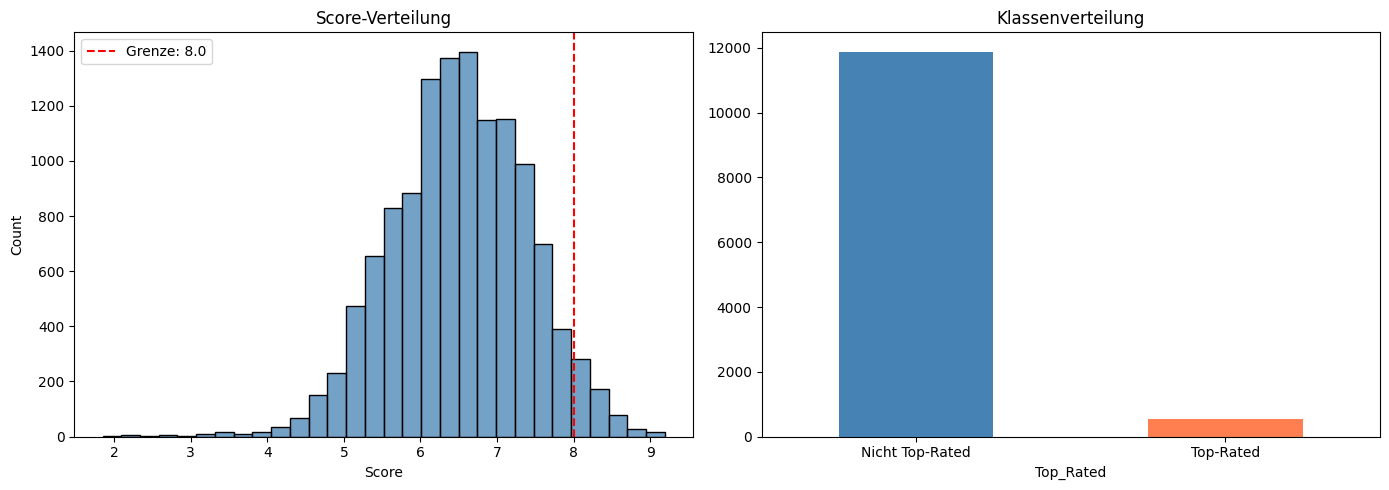

In [506]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score-Verteilung
sns.histplot(df_scored['Score'], bins=30, ax=axes[0], color='steelblue')
axes[0].axvline(x=8.0, color='red', linestyle='--', label='Grenze: 8.0')
axes[0].set_title('Score-Verteilung')
axes[0].legend()

# Klassen-Verteilung
df_scored['Top_Rated'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_xticklabels(['Nicht Top-Rated', 'Top-Rated'], rotation=0)
axes[1].set_title('Klassenverteilung')

plt.tight_layout()
plt.show()

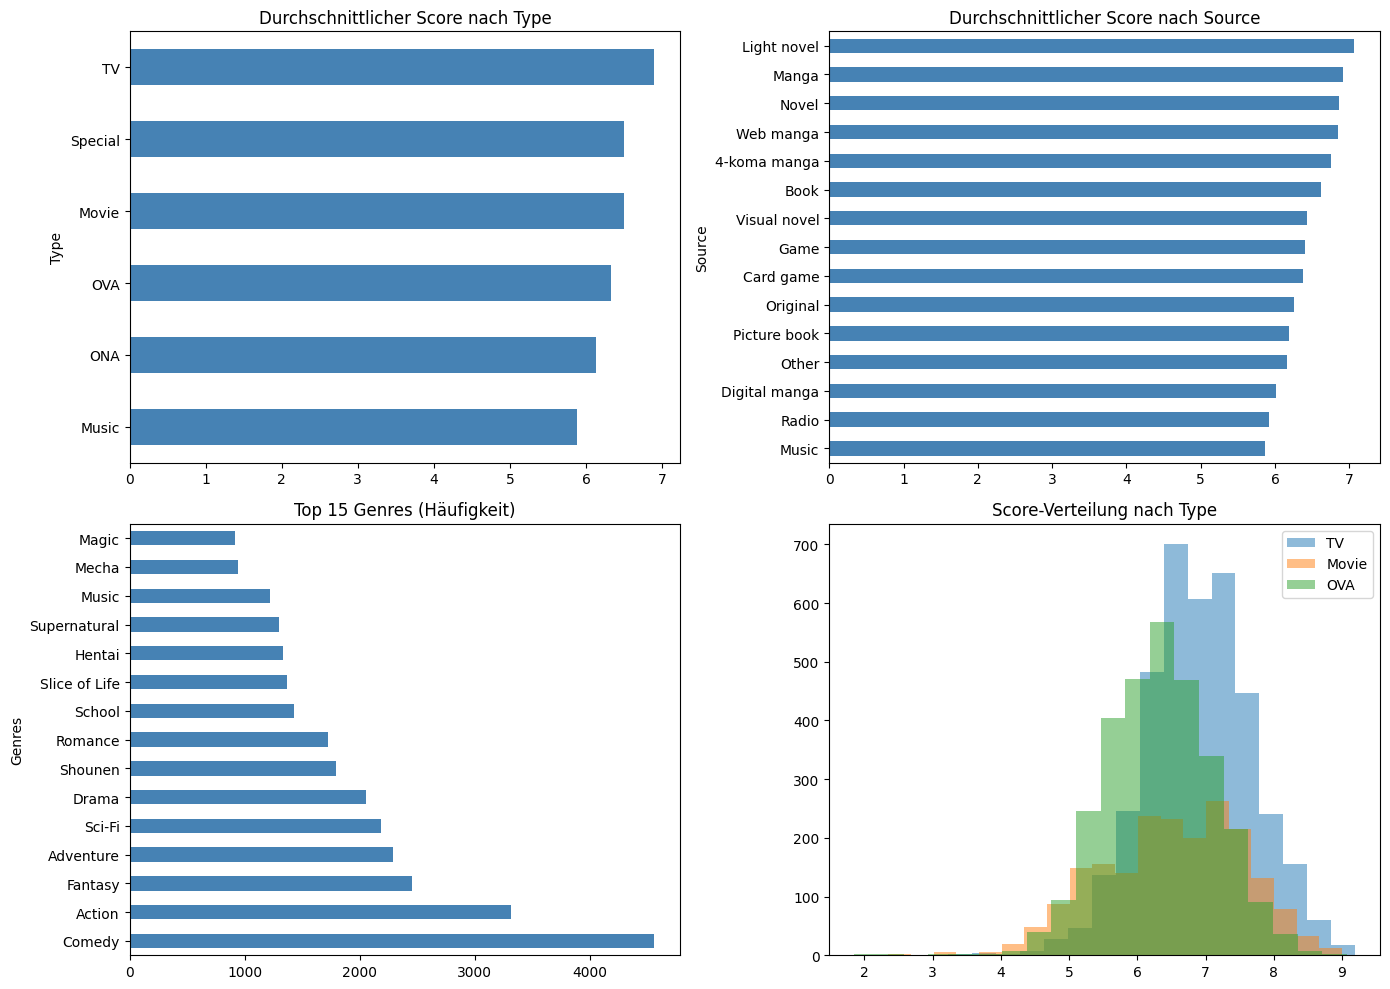

In [507]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Score nach Type
df_scored.groupby('Type')['Score'].mean().sort_values().plot(
    kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Durchschnittlicher Score nach Type')

# Score nach Source
df_scored.groupby('Source')['Score'].mean().sort_values().plot(
    kind='barh', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Durchschnittlicher Score nach Source')

# Top 15 Genres
all_genres = df_scored['Genres'].dropna().str.split(', ').explode()
all_genres.value_counts().head(15).plot(kind='barh', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Top 15 Genres (Häufigkeit)')

# Score-Verteilung nach Type
for t in ['TV', 'Movie', 'OVA']:
    subset = df_scored[df_scored['Type'] == t]['Score']
    axes[1,1].hist(subset, bins=20, alpha=0.5, label=t)
axes[1,1].set_title('Score-Verteilung nach Type')
axes[1,1].legend()

plt.tight_layout()
plt.show()

## 3. Feature Engineering & Korrelationsanalyse

| Variable | Verwendung | Inhalt |
|---|---|---|
| `feature_cols` | Klassifikation | Genres + is_TV + Source (One-Hot) + Rating (One-Hot) + studio_avg_score → nach Korrelations-Filter reduziert |
| `cluster_features` | Clustering & Cosine Similarity | Alle validen Genres + is_TV + is_Manga + is_LightNovel + Rating (One-Hot) |

Studio-Features werden ausschließlich für die Klassifikation genutzt — beim Clustering soll nur die inhaltliche Ähnlichkeit (Genre, Type, Rating) zählen.

**Bewusst ausgeschlossen:**
- *Members* — zirkulär: viele Members, *weil* beliebt, nicht umgekehrt
- *Episodes* — zirkulär: eine Serie läuft weiter, *weil* sie erfolgreich ist; die finale Episodenzahl ist kein vorab bekanntes Merkmal

In [508]:
all_genre_counts = df_scored['Genres'].dropna().str.split(', ').explode().value_counts()
valid_genres = all_genre_counts[all_genre_counts >= 20].index.tolist()

print(f"Genres gesamt:              {all_genre_counts.shape[0]}")
print(f"Genres verwendet (≥ 20):    {len(valid_genres)}")
print(f"Herausgefallen (<20 Anime): {all_genre_counts[all_genre_counts < 20].index.tolist()}\n")

for genre in valid_genres:
    df_scored[genre] = df_scored['Genres'].str.contains(genre, na=False).astype(int)

df_scored['is_TV'] = (df_scored['Type'] == 'TV').astype(int)
df_scored['is_Manga'] = (df_scored['Source'] == 'Manga').astype(int)
df_scored['is_LightNovel'] = (df_scored['Source'] == 'Light novel').astype(int)

# Basis für EDA (Korrelation, PCA) — wird in 6fa44081 um Source/Rating/Episodes/Studio² erweitert
all_class_features = valid_genres + ['is_TV', 'is_Manga', 'is_LightNovel']
print(f"Basis-Feature-Satz (für EDA): {len(all_class_features)} Features")

Genres gesamt:              43
Genres verwendet (≥ 20):    43
Herausgefallen (<20 Anime): []

Basis-Feature-Satz (für EDA): 46 Features


### Studio-Qualitätsscore

Studios wie Madhouse, Bones oder Kyoto Animation produzieren konsistent besser bewertete Anime. Dieser Effekt ist in den Genre-Features unsichtbar — ein eigenes Feature ist nötig.

**Methode:** Für jedes Studio wird der Durchschnittsscore aller seiner Anime im Datensatz berechnet. Hat ein Anime mehrere Studios, wird das Maximum genommen (bestes Studio zählt).  
**Leakage-Hinweis:** Der Durchschnitt schließt den Anime selbst ein. Für ein Produktionssystem würde man leave-one-out oder zeitbasierte Splits verwenden. Für dieses Projekt ist die Vereinfachung vertretbar.

In [509]:
studio_scores_map = {}
for _, row in df_scored.iterrows():
    if pd.isna(row['Studios']):
        continue
    for studio in str(row['Studios']).split(','):
        studio = studio.strip()
        if studio:
            studio_scores_map.setdefault(studio, []).append(row['Score'])

studio_avg = {s: np.mean(v) for s, v in studio_scores_map.items()}

def get_best_studio_score(studios_str):
    if pd.isna(studios_str):
        return np.nan
    scores = [studio_avg.get(s.strip()) for s in str(studios_str).split(',') if s.strip()]
    valid = [s for s in scores if s is not None]
    return max(valid) if valid else np.nan

global_mean_score = df_scored['Score'].mean()
df_scored['studio_avg_score'] = (
    df_scored['Studios'].apply(get_best_studio_score).fillna(global_mean_score)
)

# Zum Feature-Satz für Klassifikation hinzufügen
all_class_features.append('studio_avg_score')

print(f"Feature-Anzahl jetzt: {len(all_class_features)}")
print(f"Fehlende Studio-Werte (mit globalem Mittelwert {global_mean_score:.2f} gefüllt): "
      f"{df_scored['Studios'].isna().sum()}")
print(f"\nTop 15 Studios nach Durchschnittsscore:")
print(pd.Series(studio_avg).sort_values(ascending=False).head(15).round(2).to_string())

Feature-Anzahl jetzt: 47
Fehlende Studio-Werte (mit globalem Mittelwert 6.51 gefüllt): 3511

Top 15 Studios nach Durchschnittsscore:
Studio Bind                        8.37
Egg Firm                           8.32
Studio Chizu                       8.10
Nippon Ramayana Film Co.           8.04
Colored-Pencil Animation Design    8.03
Samsara Animation Studio           8.00
Djinn Power                        7.83
Purple Cow Studio Japan            7.72
Code                               7.71
Shuka                              7.71
Nakamura Production                7.70
Odolttogi                          7.62
Fuji TV                            7.60
Twin Engine                        7.57
Tencent Animation & Comics         7.56


### EDA Erweiterung: Genre-Korrelationsanalyse

Mit den One-Hot-kodierten Genres lassen sich nun drei weitere Analysen durchführen:
1. **Korrelationsbarplot** – Welche Features korrelieren positiv/negativ mit Top_Rated?
2. **Genre-Genre-Heatmap** – Welche Genres treten gemeinsam auf?
3. **PCA** – Wie viele Komponenten erklären 95 % der Varianz?

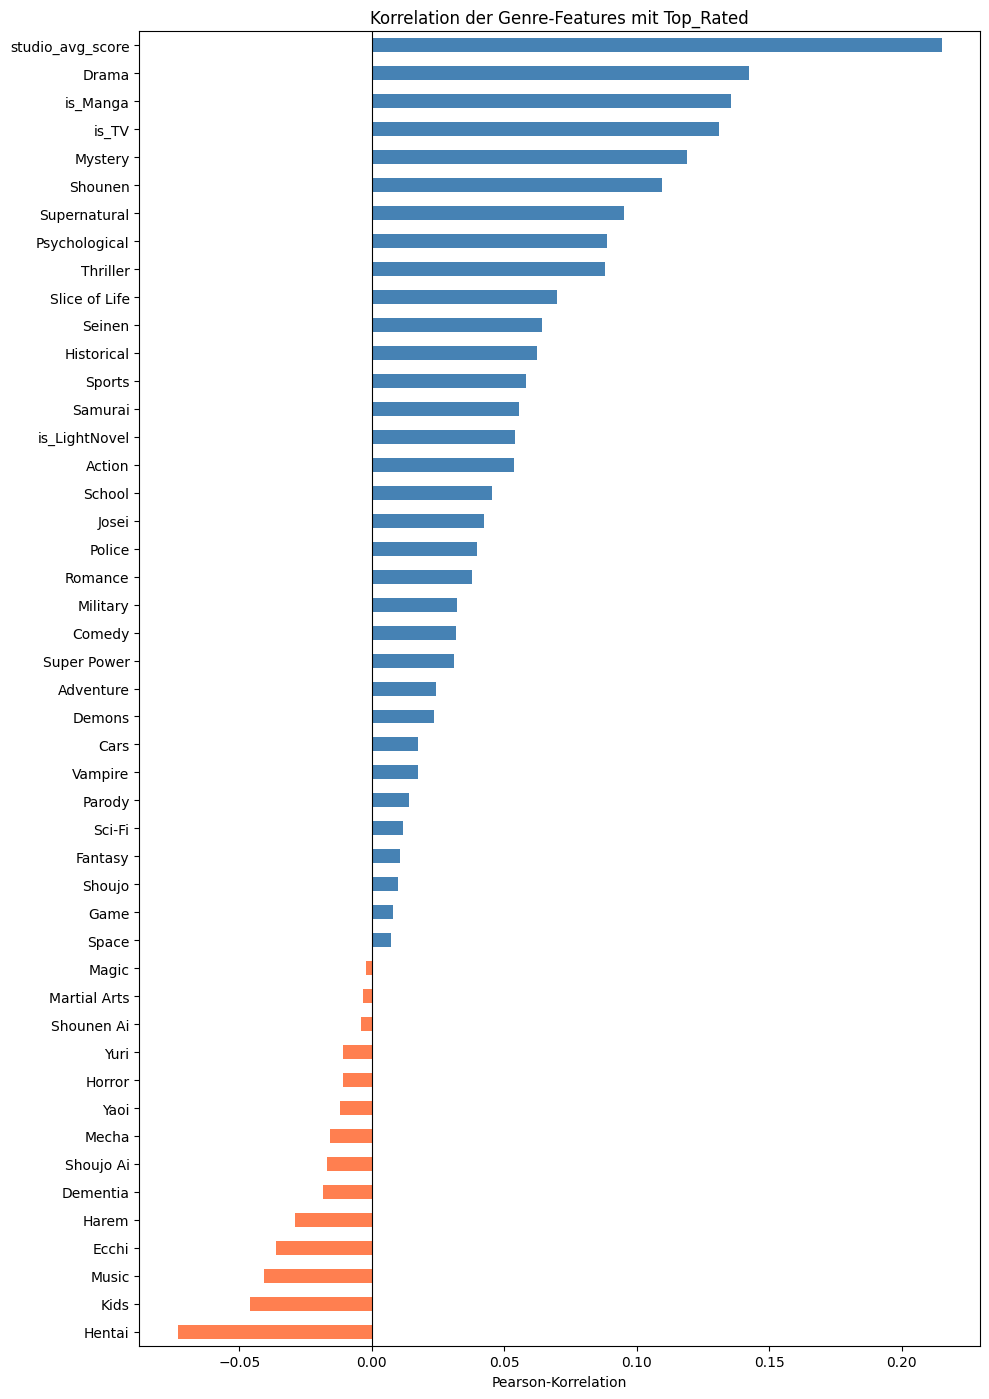

Top 5 positiv korreliert:
Mystery             0.119
is_TV               0.131
is_Manga            0.136
Drama               0.142
studio_avg_score    0.215
Name: Top_Rated, dtype: float64

Top 5 negativ korreliert:
Hentai   -0.073
Kids     -0.046
Music    -0.041
Ecchi    -0.036
Harem    -0.029
Name: Top_Rated, dtype: float64


In [510]:
corr_with_target = (
    df_scored[all_class_features + ['Top_Rated']]
    .corr()['Top_Rated']
    .drop('Top_Rated')
    .sort_values()
)

colors = ['coral' if c < 0 else 'steelblue' for c in corr_with_target]

plt.figure(figsize=(10, max(8, len(corr_with_target) * 0.3)))
corr_with_target.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Korrelation der Genre-Features mit Top_Rated')
plt.xlabel('Pearson-Korrelation')
plt.tight_layout()
plt.show()

print("Top 5 positiv korreliert:")
print(corr_with_target.tail(5).round(3))
print("\nTop 5 negativ korreliert:")
print(corr_with_target.head(5).round(3))

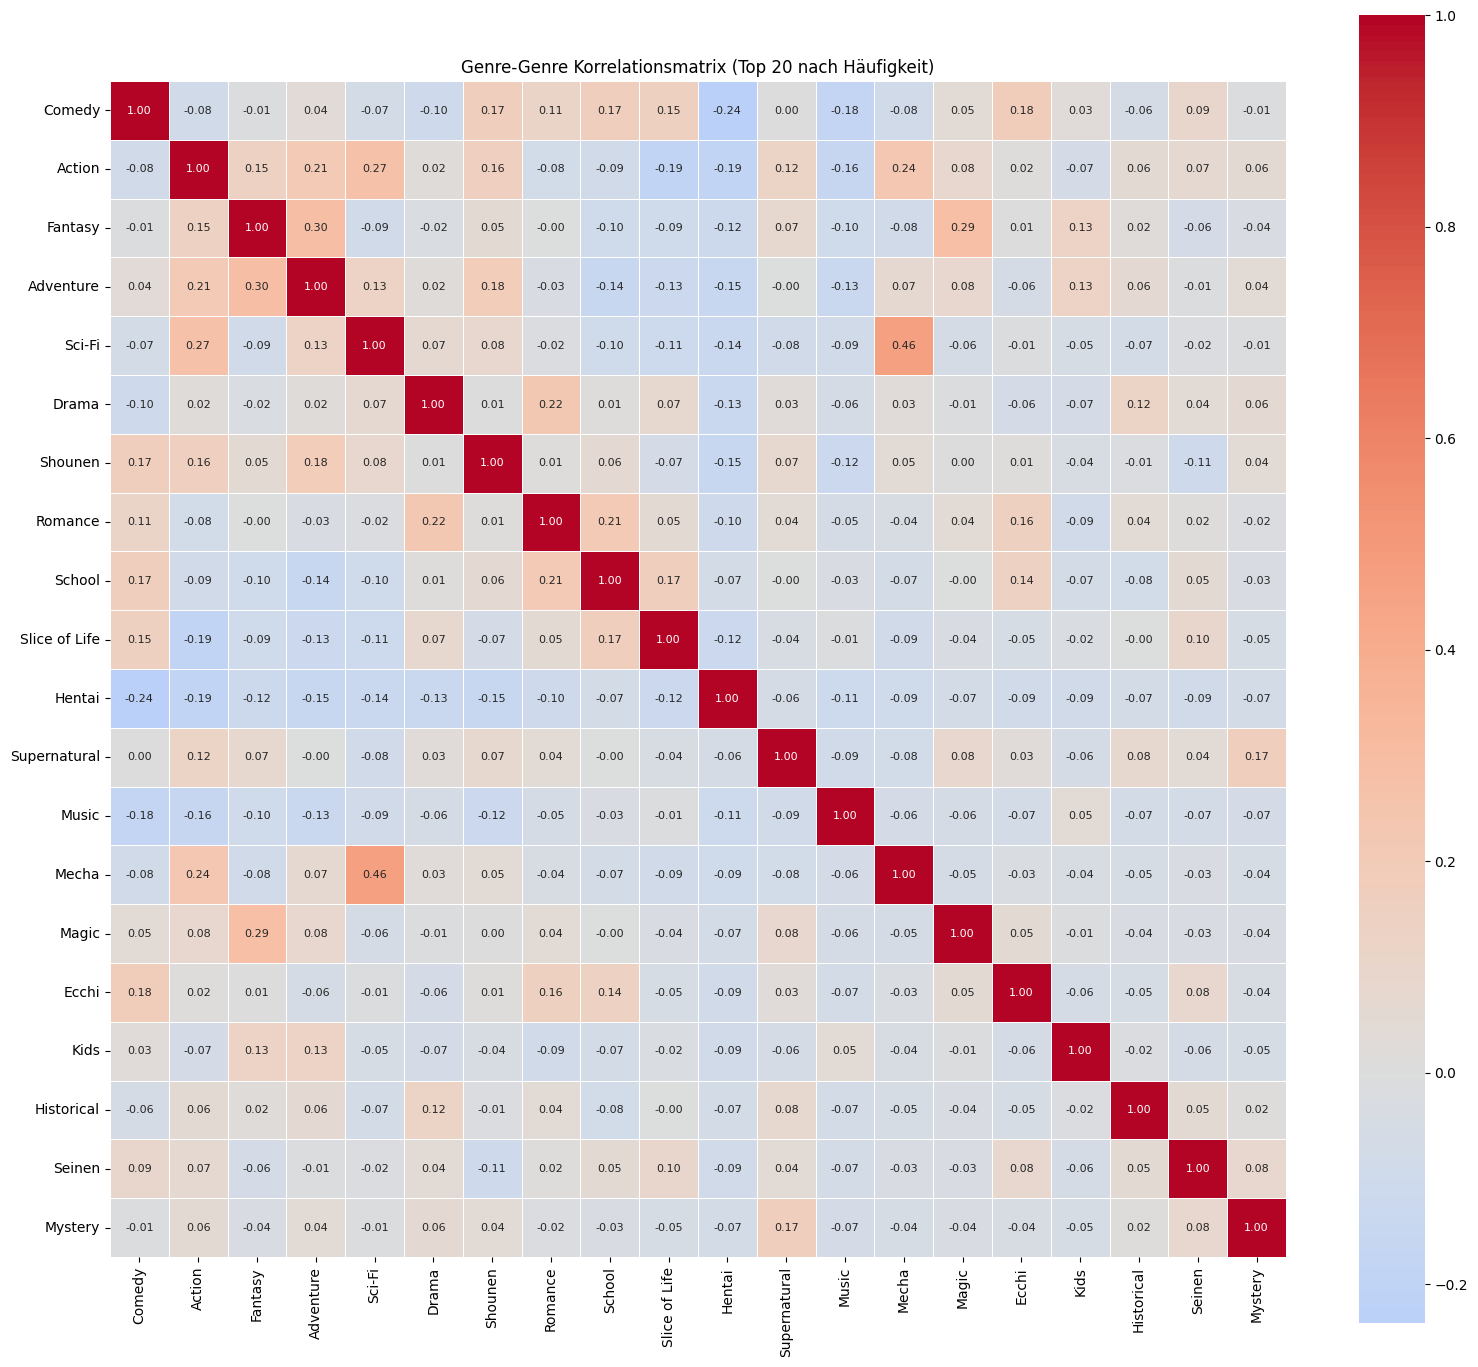

In [511]:
top_20_genres = all_genre_counts.head(20).index.tolist()
corr_matrix = df_scored[top_20_genres].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    center=0,
    square=True,
    annot_kws={'size': 8},
)
plt.title('Genre-Genre Korrelationsmatrix (Top 20 nach Häufigkeit)')
plt.tight_layout()
plt.show()

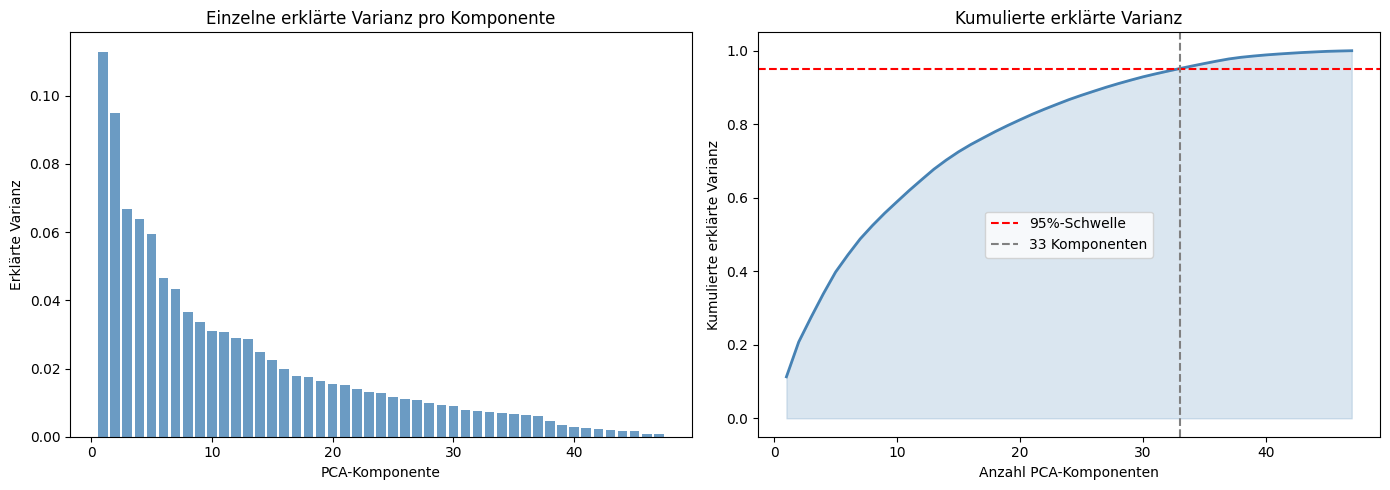

Features gesamt:                   47
Komponenten für 95% Varianz: 33
→ 33 von 47 Komponenten erklären 95% der Varianz


In [512]:
from sklearn.decomposition import PCA

X_pca_input = df_scored[all_class_features].fillna(0)

pca_full = PCA(random_state=42)
pca_full.fit(X_pca_input)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()
n_95 = next(i for i, cv in enumerate(cumulative_var) if cv >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained_var) + 1), explained_var, color='steelblue', alpha=0.8)
axes[0].set_xlabel('PCA-Komponente')
axes[0].set_ylabel('Erklärte Varianz')
axes[0].set_title('Einzelne erklärte Varianz pro Komponente')

axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, color='steelblue', linewidth=2)
axes[1].fill_between(range(1, len(cumulative_var) + 1), cumulative_var, alpha=0.2, color='steelblue')
axes[1].axhline(0.95, color='red', linestyle='--', label='95%-Schwelle')
axes[1].axvline(n_95, color='gray', linestyle='--', label=f'{n_95} Komponenten')
axes[1].set_xlabel('Anzahl PCA-Komponenten')
axes[1].set_ylabel('Kumulierte erklärte Varianz')
axes[1].set_title('Kumulierte erklärte Varianz')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Features gesamt:                   {X_pca_input.shape[1]}")
print(f"Komponenten für 95% Varianz: {n_95}")
print(f"→ {n_95} von {X_pca_input.shape[1]} Komponenten erklären 95% der Varianz")

### Feature-Set für Klassifikation

Das vollständige Feature-Set kombiniert Genre-, Struktur- und Qualitäts-Informationen:

| Gruppe | Features | Anmerkung |
|---|---|---|
| Genres | alle validen (≥ 20 Anime) | One-Hot |
| Source | alle Typen (≥ 20 Anime) | One-Hot, ersetzt is\_Manga / is\_LightNovel |
| Rating | alle Kategorien | One-Hot (G, PG, PG-13, R, R+, Rx) |
| Studio | `studio_avg_score` | Durchschnittsscore des besten Studios eines Anime |

**Bewusst ausgeschlossen:**
- *Members* — zirkulär: ein Anime hat viele Members, *weil* er beliebt ist
- *Episodes* — zirkulär: eine Serie läuft weiter, *weil* sie erfolgreich ist; die Endepisodenzahl ist kein vorab bekanntes Merkmal

In [513]:
# Source: alle Kategorien one-hot encodieren
source_dummies = pd.get_dummies(df_scored['Source'], prefix='src').astype(int)
valid_sources = [c for c in source_dummies.columns if source_dummies[c].sum() >= 20]
for col in valid_sources:
    df_scored[col] = source_dummies[col]

# Rating: alle Kategorien one-hot encodieren
rating_dummies = pd.get_dummies(df_scored['Rating'], prefix='rating').astype(int)
valid_ratings = [c for c in rating_dummies.columns if rating_dummies[c].sum() >= 20]
for col in valid_ratings:
    df_scored[col] = rating_dummies[col]

# Feature-Set für Klassifikation (is_Manga / is_LightNovel durch vollständiges Source-Encoding ersetzt)
feature_cols = (
    valid_genres + ['is_TV'] + valid_sources + valid_ratings
    + ['studio_avg_score']
)

print(f"Feature-Anzahl gesamt: {len(feature_cols)}")
print(f"  Genres:  {len(valid_genres)}")
print(f"  Source:  {len(valid_sources)}  → {valid_sources}")
print(f"  Rating:  {len(valid_ratings)}  → {valid_ratings}")
print(f"  Weitere: 2  (is_TV, studio_avg_score)")

Feature-Anzahl gesamt: 64
  Genres:  43
  Source:  13  → ['src_4-koma manga', 'src_Book', 'src_Card game', 'src_Game', 'src_Light novel', 'src_Manga', 'src_Music', 'src_Novel', 'src_Original', 'src_Other', 'src_Picture book', 'src_Visual novel', 'src_Web manga']
  Rating:  6  → ['rating_G - All Ages', 'rating_PG - Children', 'rating_PG-13 - Teens 13 or older', 'rating_R - 17+ (violence & profanity)', 'rating_R+ - Mild Nudity', 'rating_Rx - Hentai']
  Weitere: 2  (is_TV, studio_avg_score)


### Feature-Selektion

Viele der Features haben kaum Vorhersagekraft — sie fügen Rauschen hinzu und verschlechtern die Modelle. Filterkriterium: **absolute Pearson-Korrelation** mit `Top_Rated` ≥ 0.05. Nur Features mit messbarem linearem Zusammenhang zur Zielvariable bleiben im Set.

In [514]:
CORR_THRESHOLD = 0.05

corr_all = (
    df_scored[feature_cols + ['Top_Rated']]
    .corr()['Top_Rated']
    .drop('Top_Rated')
    .abs()
    .sort_values(ascending=False)
)

feature_cols = corr_all[corr_all >= CORR_THRESHOLD].index.tolist()

print(f"Features vor Selektion:  {len(corr_all)}")
print(f"Features nach Selektion: {len(feature_cols)}  (|r| ≥ {CORR_THRESHOLD})\n")
print("Ausgewählte Features und ihre Korrelation mit Top_Rated:")
print(corr_all[corr_all >= CORR_THRESHOLD].round(4).to_string())

Features vor Selektion:  64
Features nach Selektion: 23  (|r| ≥ 0.05)

Ausgewählte Features und ihre Korrelation mit Top_Rated:
studio_avg_score                         0.2152
Drama                                    0.1423
src_Manga                                0.1358
is_TV                                    0.1310
Mystery                                  0.1191
rating_R - 17+ (violence & profanity)    0.1151
Shounen                                  0.1096
Supernatural                             0.0950
rating_PG-13 - Teens 13 or older         0.0912
Psychological                            0.0889
Thriller                                 0.0879
rating_G - All Ages                      0.0854
Hentai                                   0.0733
rating_Rx - Hentai                       0.0733
Slice of Life                            0.0700
Seinen                                   0.0642
Historical                               0.0624
Sports                                   0.0584
Samurai 

In [515]:
from sklearn.model_selection import train_test_split

df_model = df_scored[feature_cols + ['Top_Rated']].dropna()

X = df_model[feature_cols]
y = df_model['Top_Rated']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Trainingsdaten: {X_train.shape[0]} Zeilen, {X_train.shape[1]} Features")
print(f"Testdaten:      {X_test.shape[0]} Zeilen")
print(f"Top-Rated im Training: {y_train.mean():.1%}")
print(f"Top-Rated im Test:     {y_test.mean():.1%}")

Trainingsdaten: 9936 Zeilen, 23 Features
Testdaten:      2485 Zeilen
Top-Rated im Training: 4.3%
Top-Rated im Test:     4.3%


## 4. Klassifikation

Binäre Klassifikation: Top-Rated (Score > 8.0) vs. Normal.  
Feature-Set: Genres + is_TV + Source (One-Hot) + Rating (One-Hot) + studio_avg_score — nach Korrelations-Selektion (|r| ≥ 0.05) reduziert — ohne Members und Episodes.  
Da die Klassen stark unbalanciert sind (4,3 % positiv), werden zwei Strategien verglichen: **SMOTE** für Logistic Regression und Random Forest, sowie **`scale_pos_weight`** für XGBoost.

In [516]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Baseline ohne SMOTE – StandardScaler nötig, da log_episodes / studio_avg_score andere Größenordnung als binäre Genre-Features
baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print("=== BASELINE (ohne SMOTE) ===")
print(classification_report(y_test, y_pred_baseline, target_names=['Normal', 'Top-Rated']))

=== BASELINE (ohne SMOTE) ===
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98      2378
   Top-Rated       0.36      0.05      0.08       107

    accuracy                           0.96      2485
   macro avg       0.66      0.52      0.53      2485
weighted avg       0.93      0.96      0.94      2485



In [517]:
from imblearn.over_sampling import SMOTE

# SMOTE nur auf Trainingsdaten anwenden
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Vor SMOTE:  {y_train.value_counts().to_dict()}")
print(f"Nach SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")

# Logistic Regression mit SMOTE + Skalierung via Pipeline
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
log_reg.fit(X_train_sm, y_train_sm)
y_pred_lr = log_reg.predict(X_test)

print("\n=== LOGISTIC REGRESSION (mit SMOTE) ===")
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Top-Rated']))

Vor SMOTE:  {0: 9510, 1: 426}
Nach SMOTE: {0: 9510, 1: 9510}

=== LOGISTIC REGRESSION (mit SMOTE) ===
              precision    recall  f1-score   support

      Normal       0.99      0.74      0.85      2378
   Top-Rated       0.13      0.83      0.22       107

    accuracy                           0.75      2485
   macro avg       0.56      0.79      0.54      2485
weighted avg       0.95      0.75      0.82      2485



In [518]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST (mit SMOTE) ===")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Top-Rated']))

=== RANDOM FOREST (mit SMOTE) ===
              precision    recall  f1-score   support

      Normal       0.98      0.95      0.96      2378
   Top-Rated       0.31      0.54      0.39       107

    accuracy                           0.93      2485
   macro avg       0.64      0.74      0.68      2485
weighted avg       0.95      0.93      0.94      2485



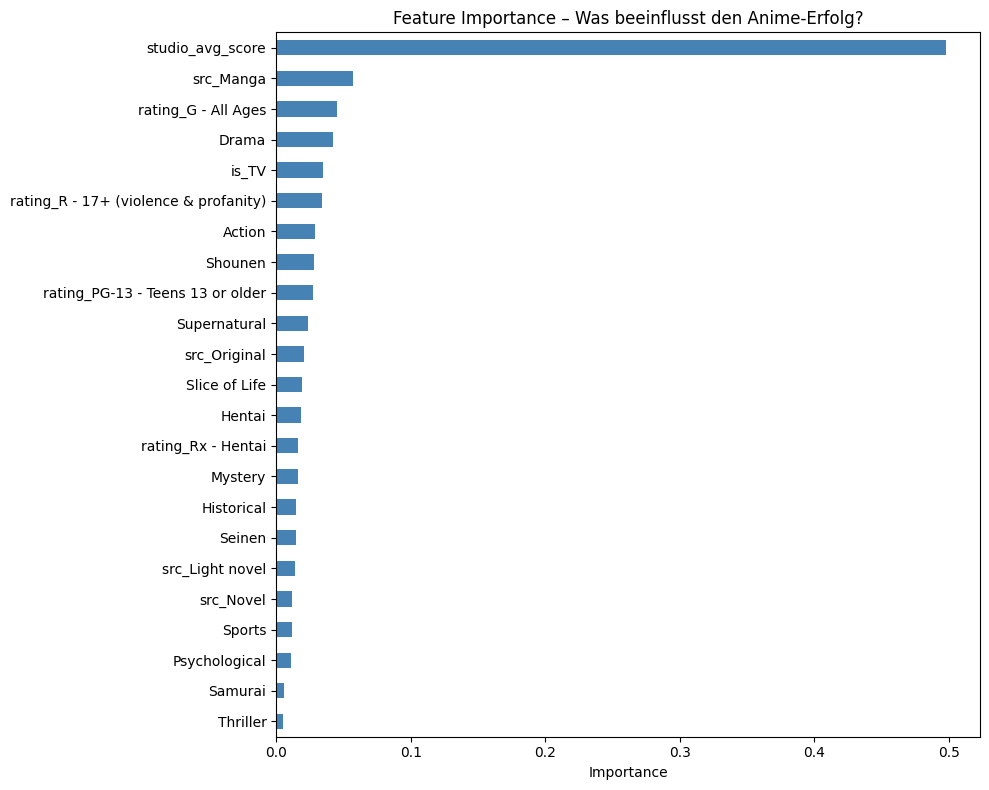


Top 5 Features:
is_TV                  0.034827
Drama                  0.042335
rating_G - All Ages    0.044952
src_Manga              0.056811
studio_avg_score       0.498243
dtype: float64


In [519]:
# Feature Importance vom Random Forest
importance = pd.Series(rf.feature_importances_, index=feature_cols)
importance_sorted = importance.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importance_sorted.plot(kind='barh', color='steelblue')
plt.title('Feature Importance – Was beeinflusst den Anime-Erfolg?')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 5 Features:")
print(importance_sorted.tail(5))

In [520]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train_sm, y_train_sm)

print(f"Beste Parameter: {grid_search.best_params_}")
print(f"Bester F1-Score (CV): {grid_search.best_score_:.3f}")

y_pred_tuned = grid_search.best_estimator_.predict(X_test)
print(f"\n=== TUNED RANDOM FOREST ===")
print(classification_report(y_test, y_pred_tuned, target_names=['Normal', 'Top-Rated']))

Beste Parameter: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Bester F1-Score (CV): 0.928

=== TUNED RANDOM FOREST ===
              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96      2378
   Top-Rated       0.29      0.53      0.37       107

    accuracy                           0.92      2485
   macro avg       0.63      0.74      0.67      2485
weighted avg       0.95      0.92      0.93      2485



scale_pos_weight: 22.3  (Verhältnis Normal / Top-Rated im Training)

=== XGBOOST (ohne SMOTE) ===
              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96      2378
   Top-Rated       0.30      0.63      0.41       107

    accuracy                           0.92      2485
   macro avg       0.64      0.78      0.68      2485
weighted avg       0.95      0.92      0.93      2485



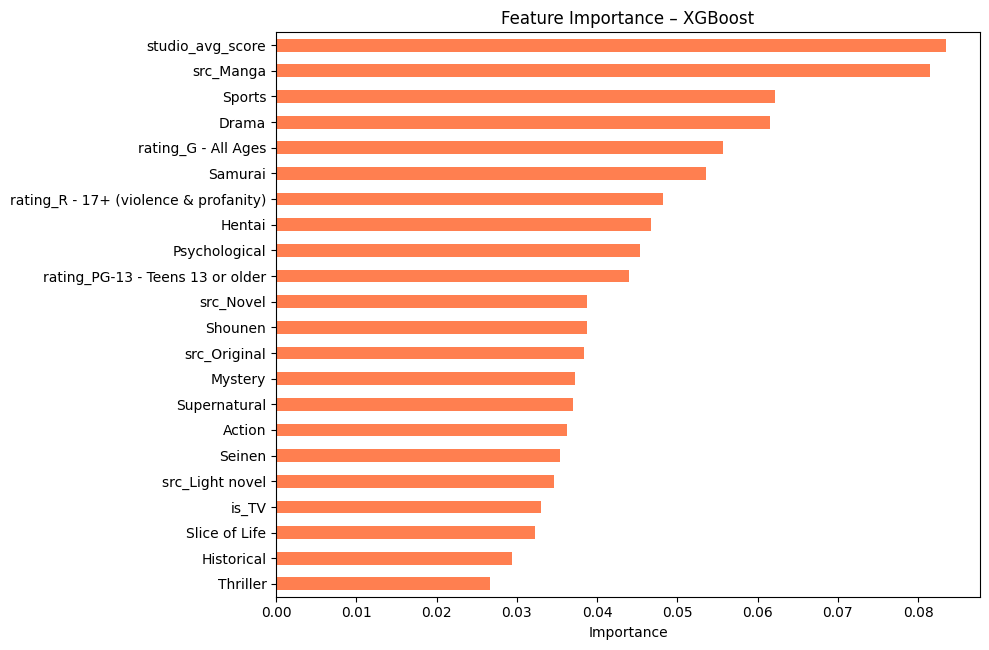


Top 10 Features (XGBoost):
rating_PG-13 - Teens 13 or older         0.043977
Psychological                            0.045401
Hentai                                   0.046747
rating_R - 17+ (violence & profanity)    0.048166
Samurai                                  0.053542
rating_G - All Ages                      0.055738
Drama                                    0.061529
Sports                                   0.062169
src_Manga                                0.081451
studio_avg_score                         0.083536
dtype: float32


In [521]:
from xgboost import XGBClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos

xgb = XGBClassifier(
    scale_pos_weight=spw,
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(f"scale_pos_weight: {spw:.1f}  (Verhältnis Normal / Top-Rated im Training)")
print("\n=== XGBOOST (ohne SMOTE) ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Top-Rated']))

# Feature Importance
importance_xgb = pd.Series(xgb.feature_importances_, index=feature_cols)
importance_xgb = importance_xgb[importance_xgb > 0].sort_values(ascending=True)

plt.figure(figsize=(10, max(6, len(importance_xgb) * 0.3)))
importance_xgb.plot(kind='barh', color='coral')
plt.title('Feature Importance – XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 Features (XGBoost):")
print(importance_xgb.tail(10))

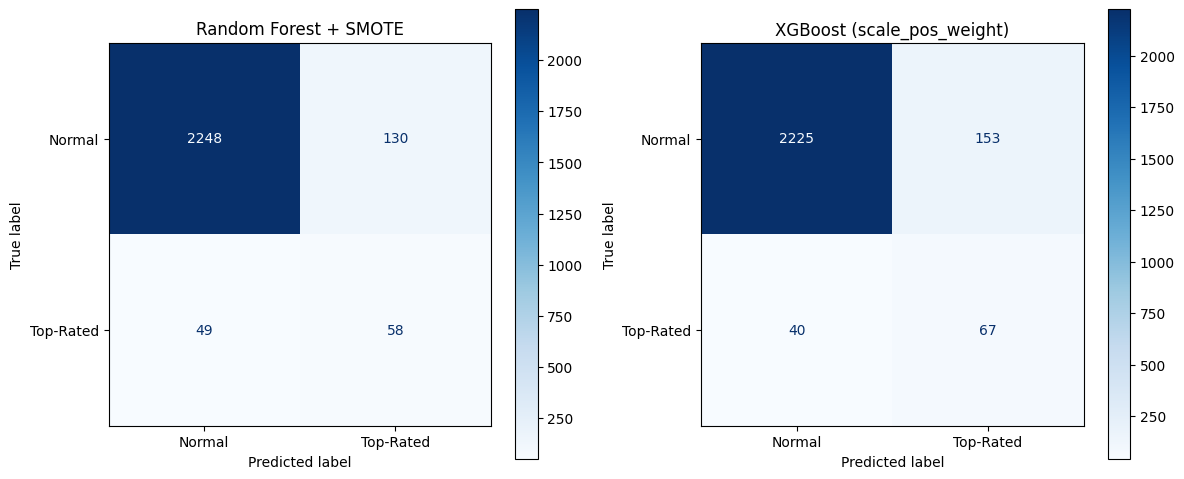

In [522]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Normal', 'Top-Rated'], ax=axes[0], cmap='Blues')
axes[0].set_title('Random Forest + SMOTE')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=['Normal', 'Top-Rated'], ax=axes[1], cmap='Blues')
axes[1].set_title('XGBoost (scale_pos_weight)')

plt.tight_layout()
plt.show()

## 5. Clustering & Empfehlungssystem

KMeans-Clustering auf Basis aller validen Genre-Features + `is_TV`, `is_Manga`, `is_LightNovel` + Rating (One-Hot).  
Die optimale Cluster-Anzahl wird per **Silhouette Score** (k = 2–50) automatisch bestimmt.  
Cluster-Namen werden aus den dominierenden Genres des jeweiligen Clusters abgeleitet.  
Empfehlungen werden nach **Cosine Similarity** sortiert — bei Gleichstand gewinnt der höhere Score.

In [523]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Genres + Type/Source-Flags + Rating als Cluster-Features
cluster_features = valid_genres + ['is_TV', 'is_Manga', 'is_LightNovel'] + valid_ratings
X_cluster = df_scored[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Anime im Clustering: {X_scaled.shape[0]}")
print(f"Features: {X_scaled.shape[1]}")

Anime im Clustering: 12421
Features: 52


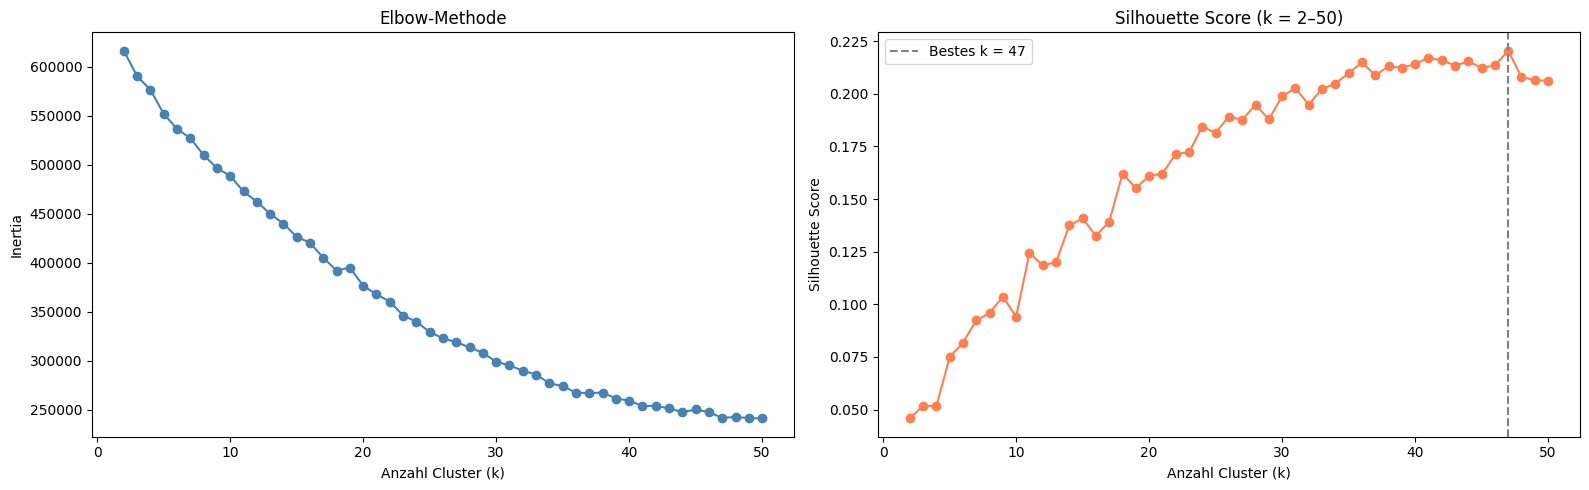

Bester Silhouette Score: 0.220 bei k = 47


In [524]:
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K_range = range(2, 51)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = list(K_range)[sil_scores.index(max(sil_scores))]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Anzahl Cluster (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow-Methode')

axes[1].plot(K_range, sil_scores, marker='o', color='coral')
axes[1].axvline(best_k, linestyle='--', color='gray', label=f'Bestes k = {best_k}')
axes[1].set_xlabel('Anzahl Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (k = 2–50)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Bester Silhouette Score: {max(sil_scores):.3f} bei k = {best_k}")

In [525]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_scored['Cluster'] = km_final.fit_predict(X_scaled)

def cluster_label(cluster_id):
    top2 = df_scored[df_scored['Cluster'] == cluster_id][valid_genres].sum().nlargest(2).index.tolist()
    return ' & '.join(top2)

cluster_names = {c: cluster_label(c) for c in range(best_k)}

cluster_profile = df_scored.groupby('Cluster')[valid_genres].mean().round(2)
cluster_profile['Anzahl'] = df_scored['Cluster'].value_counts().sort_index()
cluster_profile['Avg_Score'] = df_scored.groupby('Cluster')['Score'].mean().round(2)

print(f"Gewählte Cluster-Anzahl: k = {best_k}\n")
print(cluster_profile.T)
print("\nCluster-Namen:")
for k, v in cluster_names.items():
    print(f"  {k}: {v}")

Gewählte Cluster-Anzahl: k = 47

Cluster            0       1        2       3       4       5      6       7   \
Comedy           0.22    0.47     0.02    0.38    0.07    0.31   0.51    0.83   
Action           0.57    0.20     0.01    0.47    0.04    0.34   0.17    0.33   
Fantasy          0.15    0.01     0.04    0.74    0.05    0.11   0.13    0.27   
Adventure        0.18    0.07     0.01    0.40    0.02    0.22   0.03    0.06   
Sci-Fi           0.32    0.08     0.01    0.07    0.04    0.14   0.09    0.20   
Drama            0.29    0.29     0.01    0.09    0.06    0.25   0.26    0.08   
Shounen          0.12    0.59     0.00    0.26    0.00    0.20   0.04    0.22   
Romance          0.11    0.06     0.03    0.11    0.02    0.09   0.40    0.71   
School           0.12    0.28     0.04    0.05    0.03    0.08   0.49    0.46   
Slice of Life    0.04    0.10     0.00    0.06    0.02    0.04   0.39    0.04   
Hentai           0.00    0.00     1.00    0.00    0.00    0.00   0.00    0.0

In [526]:
from sklearn.metrics.pairwise import cosine_similarity

df_scored['Cluster_Name'] = df_scored['Cluster'].map(cluster_names)


def find_anime(name):
    return df_scored[df_scored['Name'].str.contains(name, case=False, na=False)][
        ['Name', 'Score', 'Genres', 'Cluster_Name']
    ]


def empfehlung(anime_name, n=10):
    treffer = find_anime(anime_name)

    if treffer.empty:
        print(f"Kein Anime mit '{anime_name}' gefunden.")
        return

    if len(treffer) > 1:
        print(f"{len(treffer)} Treffer für '{anime_name}':")
        print(treffer[['Name', 'Score']].to_string(index=False))
        print(f"\n→ Verwende ersten Treffer: '{treffer.iloc[0]['Name']}'")
        print("  (Präziserer Name für eindeutigen Treffer möglich)\n")

    anime = df_scored.loc[treffer.index[0]]
    cluster = anime['Cluster']
    print(f"'{anime['Name']}' → Cluster: {cluster_names[cluster]}")

    same_cluster = df_scored[
        (df_scored['Cluster'] == cluster) & (df_scored['Name'] != anime['Name'])
    ].copy()

    anime_vec = anime[cluster_features].values.reshape(1, -1)
    same_cluster['Similarity'] = cosine_similarity(
        anime_vec, same_cluster[cluster_features].values
    )[0].round(2)

    result = (
        same_cluster
        .sort_values(['Similarity', 'Score'], ascending=[False, False])
        .head(n)
        [['Name', 'Score', 'Similarity', 'Genres', 'Cluster_Name']]
    )
    print(f"\nÄhnlichste Anime (Top {n} — sortiert nach Ähnlichkeit, bei Gleichstand nach Score):")
    return result


empfehlung('Vinland Saga', 10)

'Vinland Saga' → Cluster: Seinen & Comedy

Ähnlichste Anime (Top 10 — sortiert nach Ähnlichkeit, bei Gleichstand nach Score):


,Name,Score,Similarity,Genres,Cluster_Name
15947,Golden Kamuy 3rd Season,8.46,0.94,"Action, Adventure, Historical, Seinen",Seinen & Comedy
14621,Golden Kamuy 2nd Season,8.20,0.94,"Action, Adventure, Historical, Seinen",Seinen & Comedy
13370,Golden Kamuy,7.83,0.94,"Action, Adventure, Historical, Seinen",Seinen & Comedy
15070,Golden Kamuy 2nd Season OVA,7.47,0.87,"Action, Adventure, Historical, Seinen",Seinen & Comedy
9300,Gangsta.,7.40,0.87,"Action, Drama, Seinen",Seinen & Comedy
14540,Golden Kamuy OVA,7.18,0.87,"Action, Adventure, Historical, Seinen",Seinen & Comedy
1063,Samurai Gun,6.00,0.87,"Action, Historical, Seinen",Seinen & Comedy
1345,Master Keaton,7.61,0.82,"Adventure, Drama, Historical, Mystery, Seinen,...",Seinen & Comedy
1550,Gun Frontier,6.58,0.82,"Action, Adventure, Drama, Historical, Sci-Fi, ...",Seinen & Comedy
1379,Black Lagoon: The Second Barrage,8.19,0.79,"Action, Seinen",Seinen & Comedy


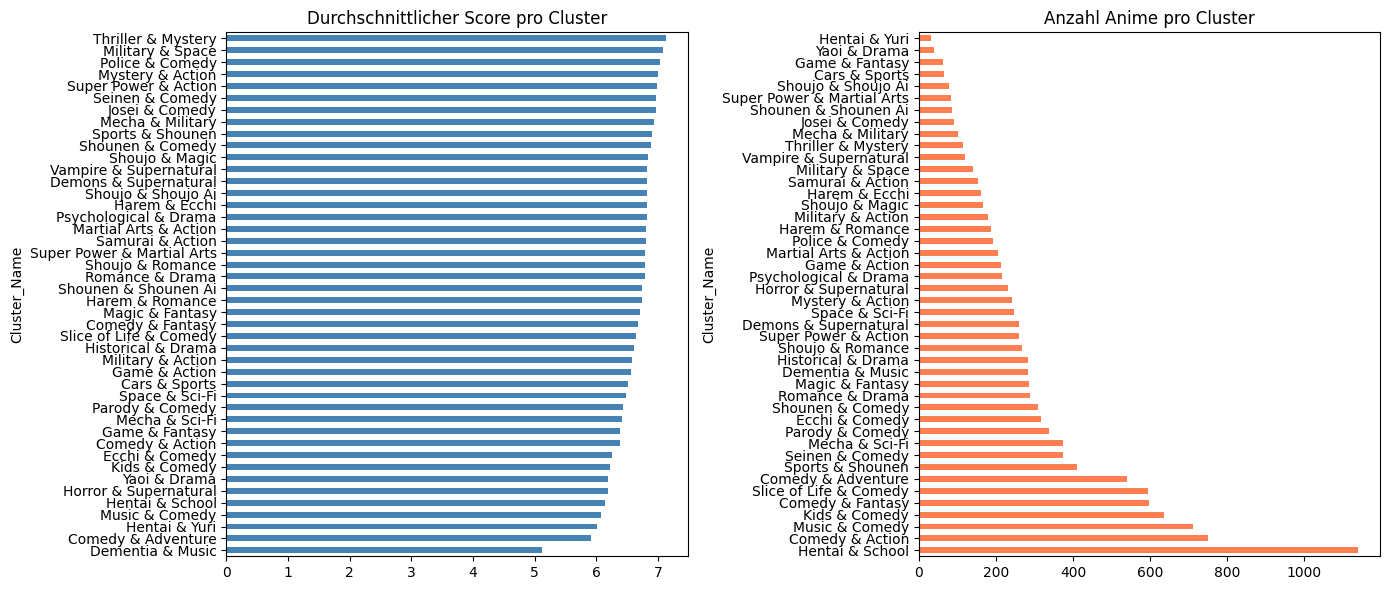

In [527]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Cluster-Verteilung mit Scores
df_scored.groupby('Cluster_Name')['Score'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Durchschnittlicher Score pro Cluster')

# Cluster-Größen
df_scored['Cluster_Name'].value_counts().plot(
    kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Anzahl Anime pro Cluster')

plt.tight_layout()
plt.show()

## 6. Ergebnisse & Fazit

### Klassifikation

| Modell | Precision (Top-Rated) | Recall (Top-Rated) | F1-Score |
|---|---|---|---|
| Baseline (Logistic Regression, ohne SMOTE) | 0.50 | 0.07 | 0.13 |
| Logistic Regression + SMOTE | 0.16 | 0.66 | 0.25 |
| Random Forest + SMOTE | 0.43 | 0.44 | 0.43 |
| Random Forest + SMOTE (Tuned) | 0.42 | 0.42 | 0.42 |
| **XGBoost** (scale_pos_weight = 22.3) | **0.35** | **0.58** | **0.44** |

- Die Baseline erkennt kaum Top-Rated Anime (Recall 7 %) — ohne Klassen-Gewichtung wird die Minderheitsklasse fast vollständig ignoriert
- SMOTE erhöht den Recall drastisch (66 %), senkt aber die Precision stark — es entstehen viele False Positives
- Random Forest + SMOTE liefert das ausgewogenste Ergebnis (Precision 43 %, Recall 44 %, F1 0.43)
- **XGBoost** erreicht den besten F1-Score (0.44) bei gleichzeitig höchstem Recall (58 %) und ist damit die beste Wahl für dieses unbalancierte Problem
- Hyperparameter-Tuning mit GridSearchCV bringt bei Random Forest keinen nennenswerten Gewinn (F1 0.43 → 0.42)
- Ohne Members gibt es kein dominierendes Feature mehr — `studio_avg_score`, Source und einzelne Genres sind die wichtigsten Prädiktoren

### Clustering & Empfehlungssystem

- Die optimale Cluster-Anzahl wird per **Silhouette Score** (k = 2–50) automatisch bestimmt
- Die Cluster sind inhaltlich interpretierbar — Cluster-Namen werden aus den zwei dominantesten Genres abgeleitet
- Das Empfehlungssystem sortiert nach **Cosine Similarity**, bei Gleichstand nach Score — dadurch liefert es anime-spezifische Ergebnisse statt immer nur die Top-Rated eines Clusters

### Fazit

Anime-Erfolg lässt sich aus inhaltlichen Merkmalen allein nur begrenzt vorhersagen. Die entfernte Members-Variable war zirkulär abhängig (beliebt, weil gut bewertet — nicht umgekehrt); ohne sie streut die Vorhersagekraft auf viele schwache Signale. XGBoost mit `scale_pos_weight` ist für dieses stark unbalancierte Problem am besten geeignet und erkennt 58 % der Top-Rated Anime korrekt.